###  Hierarchical clustering:
It is a way to group similar data points into clusters, step by step.

### How does it work?
- Imagine each data point starts as its own cluster.
- The algorithm finds the two clusters that are closest to each other and merges them into one.
- This process repeats: at each step, the two nearest clusters are merged.
- It continues until all data points are in a single cluster, or until you reach the number of clusters you want.

### Basic Terminologies:
- Dendrogram: A tree-like diagram that shows how clusters are merged step by step.
- Agglomerative: The most common type, where clusters are merged from the bottom up (starting with individual points).
- Divisive: The opposite approach, where you start with all data in one cluster and split them apart.
- Linkage: The method used to decide the distance between clusters (e.g., single, complete, average linkage).

 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets

In [6]:
iris = datasets.load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
from sklearn.preprocessing import StandardScaler
se = StandardScaler()
X_scaled = se.fit_transform(df)

In [9]:
X_scaled.shape

(150, 4)

In [10]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

In [15]:
pca_scaled = pca.fit_transform(X_scaled)
pca_scaled.shape

(150, 2)

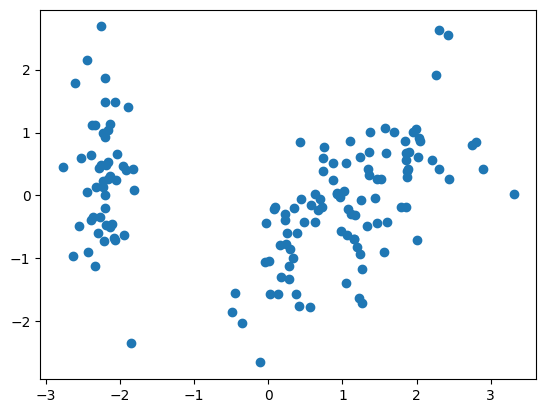

In [16]:
plt.scatter(pca_scaled[:,0],pca_scaled[:,1])

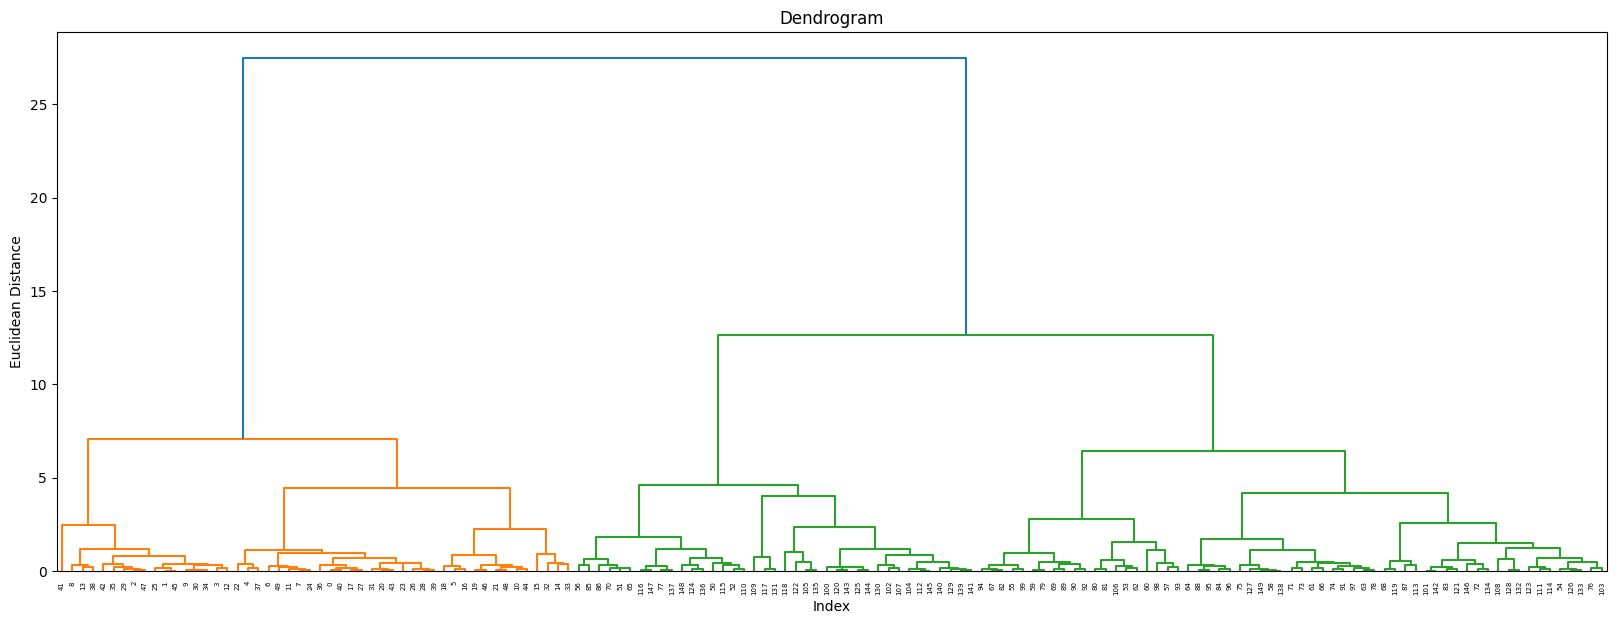

In [18]:
import scipy.cluster.hierarchy as sc
plt.figure(figsize=(20,7))
plt.title('Dendrogram')
plt.xlabel('Index')
plt.ylabel('Euclidean Distance')
sc.dendrogram(sc.linkage(pca_scaled,method='ward'))
plt.show()


In [23]:
from sklearn.cluster import AgglomerativeClustering
ac = AgglomerativeClustering(n_clusters=2, linkage='ward')
ac.fit(pca_scaled)

AgglomerativeClustering()

In [24]:
ac.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

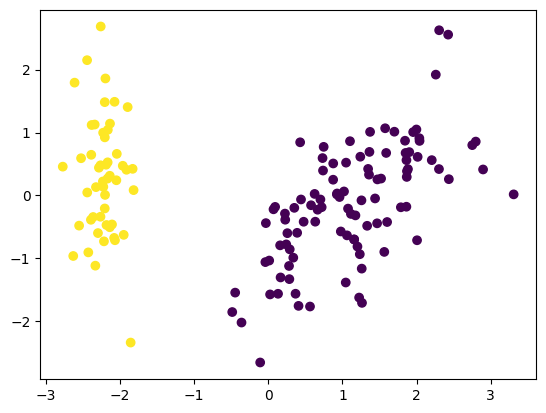

In [25]:
plt.scatter(pca_scaled[:,0],pca_scaled[:,1],c=ac.labels_)

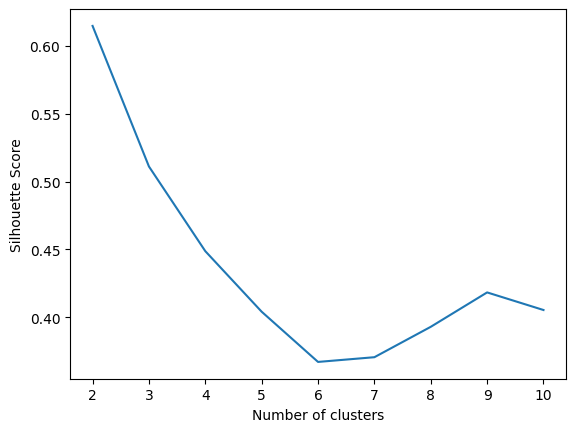

In [27]:
from sklearn.metrics import silhouette_score
silhouette_scores = []
for k in range(2,11):
    ac = AgglomerativeClustering(n_clusters=k,linkage='ward')
    ac.fit(pca_scaled)
    score = silhouette_score(pca_scaled,ac.labels_)
    silhouette_scores.append(score)

plt.plot(range(2,11),silhouette_scores)
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

